# Aufgabe 3

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import color
from skimage.io import imread

In [2]:
imgs = [imread(f"slicing/bild{i}.jpg") for i in range(1,4)]

## 3.1

Ziel: Blüten, Knospen und Zweige isolieren, Rest auf Grau (128) setzen.

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

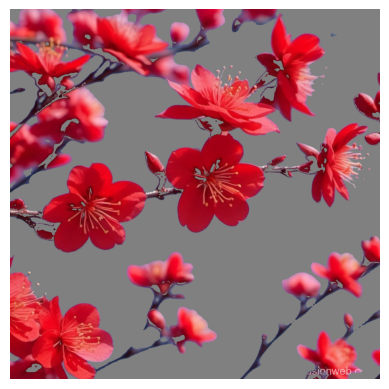

In [28]:
img_1 = imgs[0]

# RGB-basiertes Color Slicing
# Extraktion der RGB-Kanäle
R = img_1[:,:,0].astype(float)
G = img_1[:,:,1].astype(float)
B = img_1[:,:,2].astype(float)

# Prototyp 1: Rote Blüten (R dominant)
# Bedingung: R > G und R > B und R muss ausreichend hoch sein
red_flowers = (R > G) & (R > B) & (R > 100)

# Prototyp 2: Zweige/Knospen (dunkel, braun) hinzufügen
# Dunkelbraun: alle RGB-Werte niedrig und relativ gleich
dark_branches = (R < 150) & (G < 150) & (B < 150) & \
                (np.abs(R - G) < 50) & (np.abs(R - B) < 50) & (np.abs(G - B) < 50)

# Kombiniere beide Masken
mask_rgb = red_flowers | dark_branches

# Ergebnisbild: Original wo Maske wahr, sonst Grau (128)
result_rgb = np.ones_like(img_1) * 128
result_rgb[mask_rgb] = img_1[mask_rgb]

plt.imshow(result_rgb)
plt.axis("off")

## 3.2

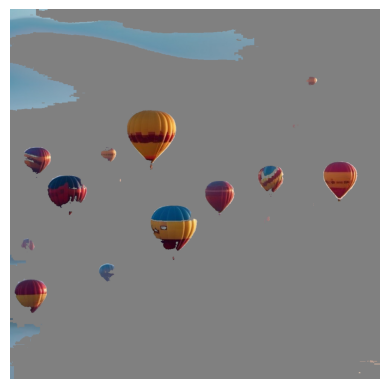

In [4]:
img_2 = imgs[1]

# LAB-basiertes Color Slicing
# Farbkomponenten a* und b*: Ballons haben intensive Werte, Himmel nahe 0
lab2 = color.rgb2lab(img_2)
a = lab2[:,:,1]  # Rot-Grün Achse
b = lab2[:,:,2]  # Gelb-Blau Achse

# Chroma: C = sqrt(a^2 + b^2) - Maß für Farbintensität
chroma = np.sqrt(a**2 + b**2)

# Maske: Hohe Chroma = intensive Ballonfarben
mask_lab = chroma > 14

# Ergebnisbild: Original wo Maske wahr, sonst Grau (128)
result_lab = np.ones_like(img_2) * 128
result_lab[mask_lab] = img_2[mask_lab]

plt.imshow(result_lab)
plt.axis("off")
plt.show()

### Begründung: LAB-Farbraum mit Chroma

- **Ballons:** Haben intensive, bunte Farben mit hohen Chroma-Werten
- **Himmel:** Hat wenig Farbintensität (Chroma nahe 0), da er sehr desaturiert ist
- **LAB-Vorteil:** Der Chroma-Wert isoliert direkt die Farbintensität unabhängig von Helligkeit

## 3.3

Text(0.5, 1.0, 'Rote Äpfel isoliert (HSV Hue-Kanal)')

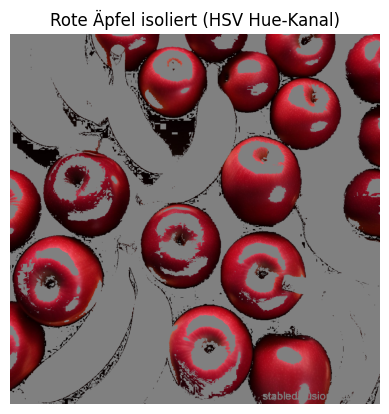

In [ ]:
img_3 = imgs[2]

# HSV-basiertes Color Slicing
# Konvertiere RGB zu HSV für bessere Farbtrennung
hsv = color.rgb2hsv(img_3)
H = hsv[:,:,0]  # Hue-Kanal
S = hsv[:,:,1]  # Saturation-Kanal
V = hsv[:,:,2]  # Value-Kanal

# Rote Äpfel haben Hue um 0 (0° - 30° bzw. 330° - 360°)
# In HSV normalisiert: Hue ∈ [0, 1]
# Rot: [0, 0.03]  [0.97, 1]
red_apples = ((H < 0.03) | (H > 0.97)) & (S > 0.6)

# Ergebnisbild: Original wo Maske wahr, sonst Grau (128)
result_hsv = np.ones_like(img_3) * 128
result_hsv[red_apples] = img_3[red_apples]

plt.imshow(result_hsv.astype(np.uint8))
plt.axis("off")
plt.title("Rote Äpfel isoliert (HSV Hue-Kanal)")

### Begründung: HSV-Farbraum mit Hue-Kanal

- **Rote Äpfel:** Haben Hue-Werte um 0° (rot), Bananen um 45-60° (gelb) → saubere Trennung in einem Kanal
- **Hue-Kanal:** Ist farbtintensitätsunabhängig und trennt Rot von Gelb optimal
- **Saturation:** Filtert unsättigte Farben (Grau, dunkler Hintergrund) aus und isoliert nur intensive Farben
- **Vorteil:** Einfacher, direkter und effizienter als RGB (dort wären mehrere korrelierte Bedingungen nötig)